In [7]:
#1
import tensorflow as tf

print('Eager Execution :' , tf.executing_eagerly())
a = tf.constant([[2,3],[5,6]])
b = tf.constant([[1,2],[3,4]])
matmultification = tf.matmul(a,b)
add=tf.add(a,b)
mul=tf.multiply(a,b)

print(matmultification)
print(add)
print(mul)

x=tf.Variable(5.0)
for i in range (3):
  x.assign_add(2.0)
  print(x.numpy())

Eager Execution : True
tf.Tensor(
[[11 16]
 [23 34]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 3  5]
 [ 8 10]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 2  6]
 [15 24]], shape=(2, 2), dtype=int32)
7.0
9.0
11.0


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris

df=load_iris()
df=pd.DataFrame(df.data,columns=df.feature_names)
# df.head()

df.isnull().sum()


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


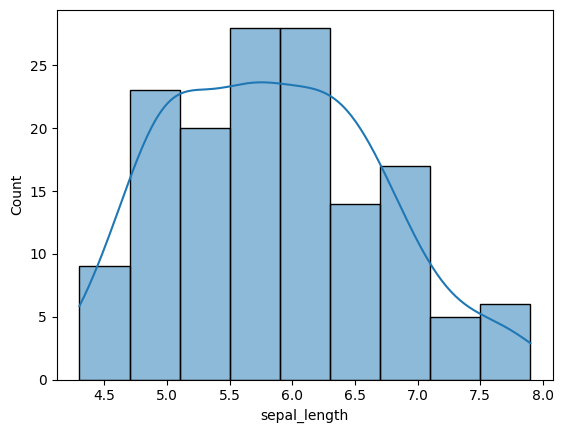

<Axes: >

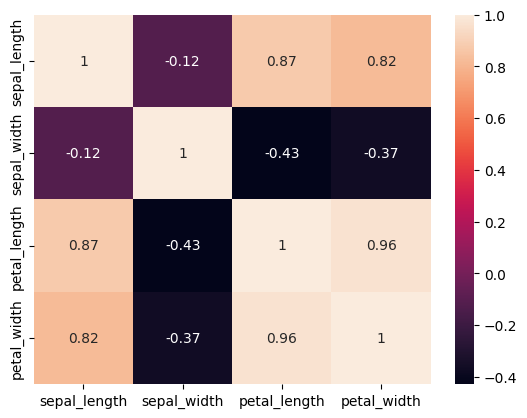

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset('iris')

df.head()

sns.histplot(df['sepal_length'] , kde=True)
plt.show()

# sns.pairplot(df)
# plt.show()
df=df.select_dtypes(include='number')
sns.heatmap(data=df.corr(), annot=True)


In [33]:
!pip install -q faiss-cpu spacy
!python -m spacy download en_core_web_md

import faiss
import numpy as np
import spacy

nlp = spacy.load('en_core_web_md')

words = ['king', 'queen', 'man', 'woman', 'apple', 'orange']
vectors = np.array([nlp(w).vector for w in words]).astype('float32')

index = faiss.IndexFlatL2(vectors.shape[1])
index.add(vectors)

query_word = 'royal'
query_vec = np.array([nlp(query_word).vector], dtype='float32')

distances, indices = index.search(query_vec, k=3)

print(f"\nQuery: {query_word}")
for i in range(3):
    print(f"{i+1}. {words[indices[0][i]]} (distance: {distances[0][i]:.4f})")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 42.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Query: royal
1. queen (distance: 62.3108)
2. king (distance: 71.0804)
3. man (distance: 75.4891)


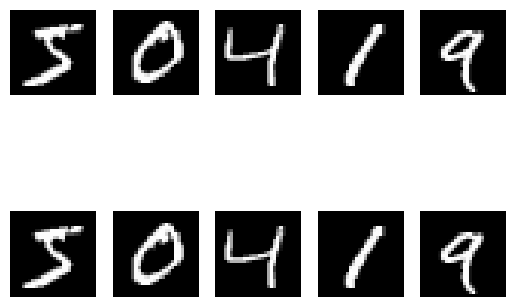

In [36]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, _), _ = mnist.load_data()
x_train = x_train.astype("float32") / 255.0

# Add and remove simple Gaussian noise
noise = tf.random.normal(x_train[:5].shape, stddev=0.5)
noisy = x_train[:5] + noise
denoised = tf.clip_by_value(noisy - noise, 0, 1)

# Show results
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(denoised[i], cmap='gray')
    plt.axis('off')
plt.show()


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]

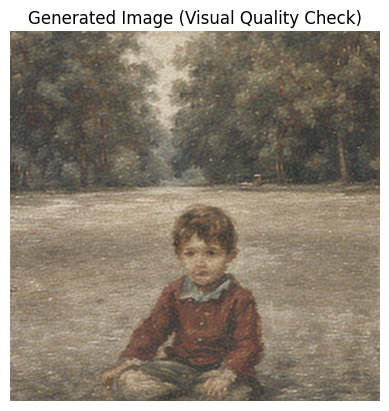

In [40]:
!pip install -q diffusers transformers accelerate torch torchvision

from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32
)


prompt = "A small boy"
image = pipe(prompt, num_inference_steps=4, guidance_scale=0.0).images[0]


plt.imshow(image)
plt.axis("off")
plt.title("Generated Image (Visual Quality Check)")
plt.show()

In [49]:
!pip install -q transformers datasets

from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import Dataset
import math, os

os.environ["WANDB_DISABLED"] = "true"

texts = [
    "AI is changing the world.",
    "Machine Learning learns from data.",
    "Generative AI creates art and text.",
    "NLP helps computers understand language."
]

data = Dataset.from_dict({"text": texts}).train_test_split(test_size=0.25)

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("distilgpt2")

def tok(e):
    t = tokenizer(e["text"], truncation=True, padding="max_length", max_length=64)
    t["labels"] = t["input_ids"].copy()
    return t

tok_data = data.map(tok, batched=True)
tok_data.set_format("torch")

args = TrainingArguments(output_dir="out", num_train_epochs=1, per_device_train_batch_size=1, report_to="none")
trainer = Trainer(model=model, args=args, train_dataset=tok_data["train"], eval_dataset=tok_data["test"])
trainer.train()

text = "AI will"
out = model.generate(**tokenizer(text, return_tensors="pt"), max_new_tokens=30)
print("\nGenerated:", tokenizer.decode(out[0], skip_special_tokens=True))

res = trainer.evaluate()
print("Perplexity:", round(math.exp(res["eval_loss"]), 2))


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Generated: AI will be a part of the future of the world.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Perplexity: 56.48


In [50]:
from transformers import pipeline
from nltk.translate.bleu_score import sentence_bleu
# tiny example
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")
article = "AI helps automate tasks. It speeds up research and product development."
ref_summary = "AI automates tasks and speeds research."
out = summarizer(article, max_length=20)[0]["summary_text"]
print("Gen:", out)
# BLEU as quick proxy (not ideal for summarization but simple)
bleu = sentence_bleu([ref_summary.split()], out.split())
print("BLEU (approx):", round(bleu,3))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu
Your min_length=56 must be inferior than your max_length=20.
Your max_length is set to 20, but your input_length is only 15. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1633: UserWarning: Unfeasible length constraints: `min_length` (56) is larger than the maximum possible length (20). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(


Gen:  AI helps automate tasks and speeds up research and product development . AI helps speed up research
BLEU (approx): 0.0


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from transformers import pipeline

# small document store
docs = [
 "TensorFlow is an ML framework.",
 "PyTorch is popular for research.",
 "FAISS provides vector search.",
 "RAG combines retrieval and generation."
]
vect = TfidfVectorizer().fit_transform(docs)
nn = NearestNeighbors(n_neighbors=2).fit(vect)
query = "how to combine retrieval with generation?"
qv = TfidfVectorizer().fit(docs).transform([query])
_, idx = nn.kneighbors(qv)
ctx = " ".join([docs[i] for i in idx[0]])
generator = pipeline("text-generation", model="gpt2")
prompt = f"Context: {ctx}\nAnswer the query: {query}\n"
print(generator(prompt, max_length=120)[0]["generated_text"])

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Context: RAG combines retrieval and generation. FAISS provides vector search.
Answer the query: how to combine retrieval with generation?
Answer: The search query can be used to retrieve the data from a database. In this example, we will use fetch to retrieve the data from the database:
SELECT Data.firstName, Data.lastName FROM Data.users WHERE Person.firstName = "John Doe";
In this example, the data from the data.users list is retrieved from the database:
SELECT Data.firstName, Data.lastName FROM Data.users WHERE Person.firstName = "John Doe";
In this example, the data from the data.users list is retrieved from the database:
SELECT Data.firstName, Data.lastName FROM Data.users WHERE Person.firstName = "John Doe";
Answer the query: what about the data from the data.users list?
Answer:
The data from the data.users list contains the data from the database.
In this case, the data from the data.users list is retrieved from the database:
SELECT Data.firstName, Data.lastName FROM Data.users 

In [53]:
from transformers import pipeline

# load small pretrained text generator
gen = pipeline("text-generation", model="distilgpt2")

# prompts that may show bias
prompts = ["The nurse said", "The engineer said", "The teacher said"]

print("=== Raw Outputs ===")
for p in prompts:
    print(p, "->", gen(p, max_length=15, do_sample=True)[0]["generated_text"])

# simple bias mitigation: filter gendered words
def mitigate(text):
    banned = ["he", "she", "him", "her"]
    words = text.split()
    return " ".join([w for w in words if w.lower() not in banned])

print("\n=== Filtered Outputs ===")
for p in prompts:
    out = gen(p, max_length=15, do_sample=True)[0]["generated_text"]
    print(p, "->", mitigate(out))


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Raw Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for that, though she did not have a lot of money for 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

The teacher said -> The teacher said she had been told she was not welcome at her family․s school.




It is understood some people had been threatened with legal action because of the threat, but not from parents.

The school announced on Monday that it would not allow its staff to conduct their own searches on school grounds, with the possibility that they could be charged with the offence.
The school said it would investigate the matter and has set a legal standard for all staff who are not currently in custody.
Bridget said it was ‒not unusual’ for teachers to be threatened with legal action because of the threats to their families.
—
The school added that the school would review whether staff had been warned about the threats.

=== Filtered Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said the man was not in a coma and was in a coma, but it is not clear why the woman was in the coma.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The engineer said -> The engineer said could not confirm whether the new bill would be approved by the House.
The teacher said -> The teacher said I was in the parking lot to get a beer and I was on the right side. When I saw that I was in the parking lot, I said, 'I came up, I've got my coffee, I'm going to be here,'" recalled. "I said, 'Well, you're going to be here, it's not fair.' I said, 'You're not going to be here.'"


In [55]:
import random

class Agent:
    def __init__(self, name): self.name = name
    def act(self, context):
        if "food" in context: return f"{self.name}: Let's cook!"
        if "danger" in context: return f"{self.name}: Let's hide!"
        return f"{self.name}: Let's explore!"

agents = [Agent("Alpha"), Agent("Beta")]

# simple environment simulation
states = ["food nearby", "danger ahead", "nothing around"]
for step in range(3):
    context = random.choice(states)
    print(f"\nEnvironment: {context}")
    for a in agents:
        print(a.act(context))



Environment: nothing around
Alpha: Let's explore!
Beta: Let's explore!

Environment: danger ahead
Alpha: Let's hide!
Beta: Let's hide!

Environment: food nearby
Alpha: Let's cook!
Beta: Let's cook!
